In [9]:
import os
import gc
import logging
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import wecopttool as wot

import FOSWEC_M4E_inputs

# Replace this import with your actual class-script filename.
# For example, if your class is saved in "foswec_m4e_study.py":
from foswec_m4e_base import FOSWECM4EStudyBase

logging.getLogger().setLevel(logging.INFO)


import itertools
import time

In [10]:
wave_periods = np.array([1, 3, 6], dtype=float)
amplitudes = np.array([0.05], dtype=float)

controller_names = np.array(
    ["P", "P_coupled", "PI", "PI_coupled", "unstructured"],
    dtype=str,
)

nfreq = 30
depth = 2.0
overwrite_bem = False
store_full_results = False

run_data_dir = "run_data"
os.makedirs(run_data_dir, exist_ok=True)

results_base_name = "coupled_controller_res"
results_nc_file = os.path.join(run_data_dir, f"{results_base_name}.nc")
x_solution_file = os.path.join(run_data_dir, f"{results_base_name}_x_solutions.npz")

bem_data_dir = "bem_data"

In [ ]:

common_study_kwargs = dict(
    m4e_inputs_module=FOSWEC_M4E_inputs,

    nfreq=nfreq,
    depth=depth,
    phase=0.0,
    wavedir=0.0,
    wave_seed=0,

    bem_data_dir=bem_data_dir,

    # Mesh
    mesh_size_factor=0.3,
    flap_mesh_size=0.1,

    # Geometry
    flap_thickness_bottom=0.04,
    flap_thickness_top=0.1,
    flap_center_distance_apart=1.44,
    flap_width=0.76,
    flap_height=0.58,
    flap_draft=0.59,
    cg_height_above_hinge=0.17,

    platform_frame_length=1.44,
    platform_frame_thickness=0.05,
    platform_frame_width=1.06,
    platform_frame_top_depth=0.53 + 0.1,
    platform_cg=(0.0, 0.0, -0.8),

    full_width=1.63,
    columns_radius=0.1,
    columns_draft=0.53 + 0.1 + 0.4,

    daq_length=0.72,
    daq_width=0.6,
    daq_height=0.2,
    daq_top_depth=0.53 + 0.1 + 0.05,

    # Rigid-body properties
    m1=189.8,
    J1=30.0,
    m2=23.1,
    J2=1.19,

    # PTO/drivetrain values from your current class setup
    gear_ratio=3.75,
    torque_constant=1.021,
    winding_resistance=1.028,
    winding_inductance=0.0,
    drivetrain_inertia=0.05,
    drivetrain_friction_aft=3.27 / 3.75**2,
    drivetrain_friction_bow=2.7 / 3.75**2,
    drivetrain_stiffness=0.0,

    # Flap pitch constraints
    max_flap_pitch_deg=30.0,
    nsubsteps_constraint=4,
    use_flap_pitch_constraints=True,

    # Stabilization
    mooring_stiffness_full=np.diag([8e3, 2e5, 2e5, 0, 0, 0, 0, 0, 0]),
    mooring_damping_full=np.diag([8e2, 1e4, 1e4, 0, 0, 0, 0, 0, 0]),
    flap_linear_damping_full=np.diag([0, 0, 0, 0, 0, 10, 0, 0, 10]),

    # Optimization
    scale_x_wec=1e1,
    scale_x_opt=1e0,
    scale_obj=1e1,
    optim_maxiter=300,
    nsubsteps_post=10,
    pto_gains_init=-1e2,

    log_level=logging.INFO,
)

In [12]:
wave_period = wave_periods[1]

wavefreq = 1.0 / wave_period

logging.info("=" * 80)
logging.info(f"Starting wave period T = {wave_period:.3f} s")
logging.info(f"Peak frequency fp = {wavefreq:.6f} Hz")
logging.info("=" * 80)

study = FOSWECM4EStudyBase(
    wavefreq=wavefreq,
    f1=wavefreq/4,
    amplitude=float(amplitudes[0]),
    **common_study_kwargs,
)

study.load_or_run_bem(overwrite=overwrite_bem)
study.setup_m4e_reduction()

print("\nPeriod setup complete:")
print(f"  T = {wave_period:.3f} s")
print(f"  wavefreq = {wavefreq:.6f} Hz")
print(f"  f1 = {study.f1:.6f} Hz")
print(f"  nfreq = {study.nfreq}")
print(f"  len(study.waves.freq) = {len(study.waves.freq)}")
print(f"  len(study.bem_data.omega) = {len(study.bem_data.omega)}")
print(f"  impedance_reduced shape = {study.impedance_reduced.shape}")


amplitude = amplitudes[0]

logging.info("-" * 80)
logging.info(
    f"Wave condition: T = {wave_period:.3f} s, A = {amplitude:.3f} m"
)
logging.info("-" * 80)

study.set_wave_amplitude(
    amplitude=float(amplitude),
    seed=0,
)

# First solve PI controller
p_case = study.solve_controller_case(
    P=True,
    I=False,
    coupled=False,
    unstructured=False,
)


print("P avg power:", p_case["summary"]["avg_power"])
#print("Unstructured avg power:", unstruct_case["summary"]["avg_power"])

x_wec_0, x_opt_0 = wot.decompose_state(p_case['results'][0].x, 5, study.nfreq)


INFO:capytaine.io.meshio:Stored 2772 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_54"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -0.8], name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio

[09:57:53] WARNING  Using the geometric centroid as the center of gravity (COG).

           WARNING  Using the center of gravity (COG) as the rotation center for hydrostatics. Note that the       
                    hydrostatics do not use the axes defined by the FloatingBody degrees of freedom, and the       
                    rotation center should be set manually when using Capytaine to calculate hydrostatics about an 
                    axis other than the COG.

INFO:capytaine.bodies.bodies:Clipping copy_of_platform+flap1+flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_60 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_61 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
The resolution of the mesh might be insufficient for omega ranging from 10.472 to 15.708.
This warning appears when the largest panel of this mesh has radius > wavelength/8.


[09:57:54] WARNING  Mesh resolution for 209 problems:                                                              
                    The resolution of the mesh might be insufficient for omega ranging from 10.472 to 15.708.      
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

...


Period setup complete:
  T = 3.000 s
  wavefreq = 0.333333 Hz
  f1 = 0.083333 Hz
  nfreq = 30
  len(study.waves.freq) = 30
  len(study.bem_data.omega) = 30
  impedance_reduced shape = (30, 5, 5)


[10:03:03] WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [2] to a
                    minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 2 has negative or close to zero terms. Shifting up elements [6] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.15e+00, 0.00e+00, 9.98e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.12e+00, 1.33e+00, 6.94e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.81e+00, 5.82e+00, -1.22e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.57e+00, 1.17e+01, -6.49e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.53e+00, 1.50e+01, -7.78e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.50e+00, 1.64e+01, -8.09e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.48e+00, 1.68e+01, -8.27e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.45e+00, 1.66e+01, -8.56e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.41e+00, 1.51e+01, -8.88e+00]
INFO:wecopttool.core:Scaled [max(

Optimization terminated successfully    (Exit mode 0)
            Current function value: -9.058584536327741
            Iterations: 15
            Function evaluations: 15
            Gradient evaluations: 15
P avg power: -0.9058584536327737


In [14]:

study.set_wave_amplitude(
    amplitude=0.25,
    seed=0,
)

# Update optimizer scaling settings
study.scale_x_wec = 1e1
study.scale_x_opt = 1e-1
study.scale_obj = 1e-2

p_case_large = study.solve_controller_case(
    P=True,
    I=False,
    coupled=False,
    unstructured=False,
)

print("Large-amplitude P avg power:", p_case_large["summary"]["avg_power"])

[10:04:00] WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [2] to a
                    minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 2 has negative or close to zero terms. Shifting up elements [6] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.15e+00, 1.43e-11, 9.98e-03]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.14e+00, 1.10e-02, 9.80e-03]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.09e+00, 6.52e-02, 8.95e-03]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.12e+00, 3.26e-01, 5.40e-03]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.03e+00, 1.38e+00, -1.33e-02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.40e+00, 7.00e+00, 5.40e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.21e+00, 1.49e+01, 2.82e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.38e+00, 1.98e+01, 5.15e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.54e+00, 1.99e+01, 5.14e+00]
INFO:wecopttool.core:Scaled [max(x_wec)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.137572968160802
            Iterations: 14
            Function evaluations: 14
            Gradient evaluations: 14
Large-amplitude P avg power: 513.7572968160799


In [5]:
pto_gains_init_values = np.array([
    -1e4,
    -3e3,
    -1e3,
    -3e2,
    -1e2,
    -3e1,
    -1e1,
    0.0,
    1e1,
    3e1,
    1e2,
    3e2,
    1e3,
    3e3,
    1e4,
])

pto_gain_sweep_results = xr.Dataset(
    data_vars={
        "avg_power": (
            ("pto_gains_init",),
            np.full(len(pto_gains_init_values), np.nan),
        ),
        "objective": (
            ("pto_gains_init",),
            np.full(len(pto_gains_init_values), np.nan),
        ),
        "success": (
            ("pto_gains_init",),
            np.full(len(pto_gains_init_values), False, dtype=bool),
        ),
        "runtime_sec": (
            ("pto_gains_init",),
            np.full(len(pto_gains_init_values), np.nan),
        ),
    },
    coords={
        "pto_gains_init": pto_gains_init_values,
    },
    attrs={
        "description": "PTO gains initial-value sweep",
        "wave_period": float(wave_period),
        "wavefreq": float(wavefreq),
        "amplitude": float(amplitude),
        "controller": "P",
        "scale_x_wec": float(common_study_kwargs["scale_x_wec"]),
        "scale_x_opt": float(common_study_kwargs["scale_x_opt"]),
        "scale_obj": float(common_study_kwargs["scale_obj"]),
    },
)

In [6]:
full_results_pto_gain_sweep = {}
x_solution_pto_gain_sweep = {}

for case_idx, pto_gains_init in enumerate(pto_gains_init_values, start=1):
    logging.info("=" * 80)
    logging.info(
        f"PTO gain sweep case {case_idx}/{len(pto_gains_init_values)}: "
        f"pto_gains_init={pto_gains_init:g}"
    )
    logging.info("=" * 80)

    case_start = time.time()

    loc = dict(pto_gains_init=pto_gains_init)

    try:
        study_kwargs = dict(common_study_kwargs)
        study_kwargs.update(
            dict(
                pto_gains_init=float(pto_gains_init),
            )
        )

        study_gain = FOSWECM4EStudyBase(
            wavefreq=wavefreq,
            amplitude=float(amplitude),
            **study_kwargs,
        )

        study_gain.load_or_run_bem(overwrite=False)
        study_gain.setup_m4e_reduction()

        study_gain.set_wave_amplitude(
            amplitude=float(amplitude),
            seed=0,
        )

        p_case = study_gain.solve_controller_case(
            P=True,
            I=False,
            coupled=False,
            unstructured=False,
        )

        runtime_sec = time.time() - case_start

        summary = p_case.get("summary", {})

        avg_power = summary.get("avg_power", np.nan)
        objective = summary.get("objective", np.nan)
        success = summary.get("success", True)

        pto_gain_sweep_results["avg_power"].loc[loc] = avg_power
        pto_gain_sweep_results["objective"].loc[loc] = objective
        pto_gain_sweep_results["success"].loc[loc] = bool(success)
        pto_gain_sweep_results["runtime_sec"].loc[loc] = runtime_sec

        key = float(pto_gains_init)
        full_results_pto_gain_sweep[key] = p_case

        if "x_opt" in p_case:
            x_solution_pto_gain_sweep[key] = p_case["x_opt"]
        elif "x" in p_case:
            x_solution_pto_gain_sweep[key] = p_case["x"]

        logging.info(
            f"Finished PTO gain case {case_idx}/{len(pto_gains_init_values)}: "
            f"pto_gains_init={pto_gains_init:g}, "
            f"avg_power={avg_power}, "
            f"objective={objective}, "
            f"success={success}, "
            f"runtime={runtime_sec:.2f} s"
        )

    except Exception:
        runtime_sec = time.time() - case_start

        pto_gain_sweep_results["success"].loc[loc] = False
        pto_gain_sweep_results["runtime_sec"].loc[loc] = runtime_sec

        logging.exception(
            f"PTO gain sweep failed for pto_gains_init={pto_gains_init:g}"
        )

INFO:capytaine.io.meshio:Stored 2772 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_18"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -0.8], name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio

Problem initialization finished in:		 0.002 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.054 seconds
Symbolic EOM computation finished in:		 0.009 seconds
Compiling EOM expressions finished in:		 0.222 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .



INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_18"), lid_mesh=None, dofs={}, name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_24"), lid_mesh=None, dofs={}, name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = [-0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initiali


[HydroAdapter] Prepared bodies:
  [1] name='platform', CoM=[ 0.   0.  -0.8]
  [2] name='flap1', CoM=[-0.72  0.   -0.42]
  [3] name='flap2', CoM=[ 0.72  0.   -0.42]


INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_24 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1_mesh"), lid_mesh=None, dofs={"platform__Surge": ..., "platform__Sway": ..., "platform__Heave": ..., "platform__Roll": ..., "platform__Pitch": ..., "platform__Yaw": ..., "flap1__Surge": ..., "flap1__Sway": ..., "flap1__Heave": ..., "flap1__Roll": ..., "flap1__Pitch": ..., "flap1__Yaw": ...}, name="platform+flap1").
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_25 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1+flap2_mesh"), lid_mesh

...

           WARNING  Real part of impedance for 2 has negative or close to zero terms. Shifting up elements [ 0 12  
                    13] to a minimum of  1e-06 N/(m/s)

[08:42:52] WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [0] to a
                    minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 4 has negative or close to zero terms. Shifting up elements [0] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.34e-01, 1.00e+03, 1.28e+02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.34e-01, 1.00e+03, 1.28e+02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.34e-01, 1.00e+03, 1.28e+02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.34e-01, 1.00e+03, 1.28e+02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.34e-01, 1.00e+03, 1.28e+02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.34e-01, 1.00e+03, 1.28e+02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.34e-01, 1.00e+03, 1.28e+02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.34e-01, 9.98e+02, 1.28e+02]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [8.34e-01, 9.88e+02, 1.27e+02]
INFO:wecopttool.core:Scaled [max(x_wec),

Optimization terminated successfully    (Exit mode 0)
            Current function value: 54.484786992825775
            Iterations: 74
            Function evaluations: 111
            Gradient evaluations: 74


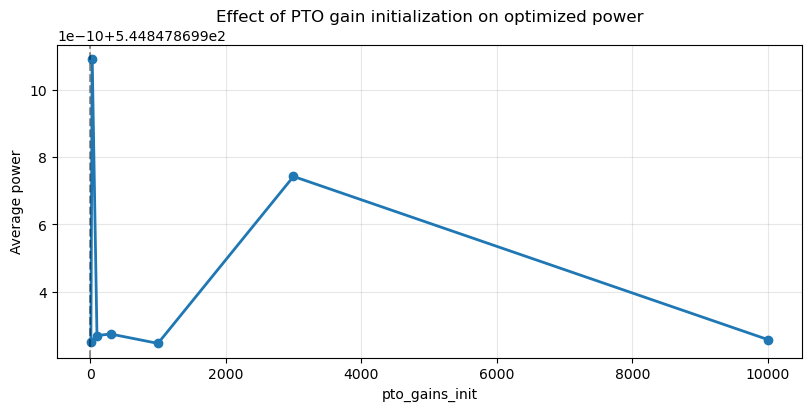

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

power = pto_gain_sweep_results["avg_power"].where(
    pto_gain_sweep_results["success"]
)

ax.plot(
    pto_gain_sweep_results["pto_gains_init"],
    power,
    marker="o",
    linewidth=2,
)

ax.axvline(0.0, color="k", linestyle="--", alpha=0.4)
ax.set_xlabel("pto_gains_init")
ax.set_ylabel("Average power")
ax.set_title("Effect of PTO gain initialization on optimized power")
ax.grid(True, alpha=0.3)

plt.show()

In [8]:
scale_x_wec_values = 1e1 * np.array([0.01, 0.1, 1.0, 10.0, 100])
scale_x_opt_values = 1e-1 * np.array([0.01, 0.1, 1.0, 10.0, 100])
scale_obj_values   = 1e-1 * np.array([0.01, 0.1, 1.0, 10.0, 100])

In [9]:
scale_sweep_results = xr.Dataset(
    data_vars={
        "avg_power": (
            ("scale_x_wec", "scale_x_opt", "scale_obj"),
            np.full(
                (
                    len(scale_x_wec_values),
                    len(scale_x_opt_values),
                    len(scale_obj_values),
                ),
                np.nan,
            ),
        ),
        "objective": (
            ("scale_x_wec", "scale_x_opt", "scale_obj"),
            np.full(
                (
                    len(scale_x_wec_values),
                    len(scale_x_opt_values),
                    len(scale_obj_values),
                ),
                np.nan,
            ),
        ),
        "success": (
            ("scale_x_wec", "scale_x_opt", "scale_obj"),
            np.full(
                (
                    len(scale_x_wec_values),
                    len(scale_x_opt_values),
                    len(scale_obj_values),
                ),
                False,
                dtype=bool,
            ),
        ),
        "runtime_sec": (
            ("scale_x_wec", "scale_x_opt", "scale_obj"),
            np.full(
                (
                    len(scale_x_wec_values),
                    len(scale_x_opt_values),
                    len(scale_obj_values),
                ),
                np.nan,
            ),
        ),
    },
    coords={
        "scale_x_wec": scale_x_wec_values,
        "scale_x_opt": scale_x_opt_values,
        "scale_obj": scale_obj_values,
    },
    attrs={
        "description": "Scaling-factor sweep for FOSWEC optimization",
        "wave_period": float(wave_period),
        "wavefreq": float(wavefreq),
        "amplitude": float(amplitude),
        "controller": "P",
    },
)

In [ ]:
x_solution_scale_sweep = {}
full_results_scale_sweep = {}

total_cases = (
    len(scale_x_wec_values)
    * len(scale_x_opt_values)
    * len(scale_obj_values)
)

case_idx = 0

for scale_x_wec, scale_x_opt, scale_obj in itertools.product(
    scale_x_wec_values,
    scale_x_opt_values,
    scale_obj_values,
):
    case_idx += 1

    logging.info("=" * 80)
    logging.info(
        f"Scale sweep case {case_idx}/{total_cases}: "
        f"scale_x_wec={scale_x_wec:g}, "
        f"scale_x_opt={scale_x_opt:g}, "
        f"scale_obj={scale_obj:g}"
    )
    logging.info("=" * 80)

    case_start = time.time()

    try:
        # Copy common kwargs and override only the scaling factors
        study_kwargs = dict(common_study_kwargs)
        study_kwargs.update(
            dict(
                scale_x_wec=float(scale_x_wec),
                scale_x_opt=float(scale_x_opt),
                scale_obj=float(scale_obj),
            )
        )

        study_scale = FOSWECM4EStudyBase(
            wavefreq=wavefreq,
            amplitude=float(amplitude),
            **study_kwargs,
        )

        # Ideally this loads existing BEM data instead of rerunning it.
        study_scale.load_or_run_bem(overwrite=False)
        study_scale.setup_m4e_reduction()

        study_scale.set_wave_amplitude(
            amplitude=float(amplitude),
            seed=0,
        )

        p_case = study_scale.solve_controller_case(
            P=True,
            I=False,
            coupled=False,
            unstructured=False,
        )

        runtime_sec = time.time() - case_start

        summary = p_case.get("summary", {})

        avg_power = summary.get("avg_power", np.nan)
        objective = summary.get("objective", np.nan)

        # If your solver stores success somewhere else, adjust this line.
        success = summary.get("success", True)

        loc = dict(
            scale_x_wec=scale_x_wec,
            scale_x_opt=scale_x_opt,
            scale_obj=scale_obj,
        )

        scale_sweep_results["avg_power"].loc[loc] = avg_power
        scale_sweep_results["objective"].loc[loc] = objective
        scale_sweep_results["success"].loc[loc] = bool(success)
        scale_sweep_results["runtime_sec"].loc[loc] = runtime_sec

        key = (
            float(scale_x_wec),
            float(scale_x_opt),
            float(scale_obj),
        )

        full_results_scale_sweep[key] = p_case

        if "x_opt" in p_case:
            x_solution_scale_sweep[key] = p_case["x_opt"]
        elif "x" in p_case:
            x_solution_scale_sweep[key] = p_case["x"]

        logging.info(
            f"Finished case {case_idx}/{total_cases}: "
            f"avg_power={avg_power}, objective={objective}, "
            f"success={success}, runtime={runtime_sec:.2f} s"
        )

    except Exception as exc:
        runtime_sec = time.time() - case_start

        loc = dict(
            scale_x_wec=scale_x_wec,
            scale_x_opt=scale_x_opt,
            scale_obj=scale_obj,
        )

        scale_sweep_results["success"].loc[loc] = False
        scale_sweep_results["runtime_sec"].loc[loc] = runtime_sec

        logging.exception(
            f"Scale sweep case failed for "
            f"scale_x_wec={scale_x_wec:g}, "
            f"scale_x_opt={scale_x_opt:g}, "
            f"scale_obj={scale_obj:g}"
        )

INFO:capytaine.io.meshio:Stored 2772 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_288"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -0.8], name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshi

Problem initialization finished in:		 0.002 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.059 seconds
Symbolic EOM computation finished in:		 0.006 seconds
Compiling EOM expressions finished in:		 0.197 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .



INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_288"), lid_mesh=None, dofs={}, name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_294"), lid_mesh=None, dofs={}, name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = [-0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initia


[HydroAdapter] Prepared bodies:
  [1] name='platform', CoM=[ 0.   0.  -0.8]
  [2] name='flap1', CoM=[-0.72  0.   -0.42]
  [3] name='flap2', CoM=[ 0.72  0.   -0.42]


INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_294 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1_mesh"), lid_mesh=None, dofs={"platform__Surge": ..., "platform__Sway": ..., "platform__Heave": ..., "platform__Roll": ..., "platform__Pitch": ..., "platform__Yaw": ..., "flap1__Surge": ..., "flap1__Sway": ..., "flap1__Heave": ..., "flap1__Roll": ..., "flap1__Pitch": ..., "flap1__Yaw": ...}, name="platform+flap1").
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_295 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1+flap2_mesh"), lid_me

...

           WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [0 4 5] 
                    to a minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 2 has negative or close to zero terms. Shifting up elements [ 0 12  
                    13] to a minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [0] to a
                    minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 4 has negative or close to zero terms. Shifting up elements [0] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.


In [ ]:
def plot_scale_sweep_heatmaps(
    ds,
    metric="avg_power",
    mask_unsuccessful=True,
    cmap="viridis",
):
    data = ds[metric]

    if mask_unsuccessful and "success" in ds:
        data = data.where(ds["success"])

    scale_x_wec_values = ds["scale_x_wec"].values
    scale_x_opt_values = ds["scale_x_opt"].values
    scale_obj_values = ds["scale_obj"].values

    n_obj = len(scale_obj_values)

    fig, axes = plt.subplots(
        1,
        n_obj,
        figsize=(4.5 * n_obj, 4.0),
        constrained_layout=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes)

    vmin = float(data.min(skipna=True))
    vmax = float(data.max(skipna=True))

    im = None

    for ax, scale_obj in zip(axes, scale_obj_values):
        z = data.sel(scale_obj=scale_obj).transpose(
            "scale_x_wec",
            "scale_x_opt",
        ).values

        im = ax.imshow(
            z,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(f"scale_obj = {scale_obj:g}")
        ax.set_xlabel("scale_x_opt")
        ax.set_ylabel("scale_x_wec")

        ax.set_xticks(np.arange(len(scale_x_opt_values)))
        ax.set_xticklabels([f"{v:g}" for v in scale_x_opt_values])

        ax.set_yticks(np.arange(len(scale_x_wec_values)))
        ax.set_yticklabels([f"{v:g}" for v in scale_x_wec_values])

        for i in range(len(scale_x_wec_values)):
            for j in range(len(scale_x_opt_values)):
                val = z[i, j]
                if np.isfinite(val):
                    ax.text(
                        j,
                        i,
                        f"{val:.3g}",
                        ha="center",
                        va="center",
                        color="white",
                        fontsize=8,
                    )

    cbar = fig.colorbar(im, ax=axes, shrink=0.9)
    cbar.set_label(metric)

    fig.suptitle(f"Scaling-factor sweep: {metric}")

    return fig, axes

fig, axes = plot_scale_sweep_heatmaps(
    scale_sweep_results,
    metric="avg_power",
)
plt.show()

In [5]:
# ---------------------------------------------------------------------
# Allocate xarray results
# ---------------------------------------------------------------------
sweep_results = xr.Dataset(
    data_vars={
        "avg_power": (
            ("controller", "wave_period", "amplitude"),
            np.full(
                (len(controller_names), len(wave_periods), len(amplitudes)),
                np.nan,
            ),
        ),
        "objective": (
            ("controller", "wave_period", "amplitude"),
            np.full(
                (len(controller_names), len(wave_periods), len(amplitudes)),
                np.nan,
            ),
        ),
        "success": (
            ("controller", "wave_period", "amplitude"),
            np.full(
                (len(controller_names), len(wave_periods), len(amplitudes)),
                False,
                dtype=bool,
            ),
        ),
    },
    coords={
        "controller": controller_names,
        "wave_period": wave_periods,
        "amplitude": amplitudes,
    },
    attrs={
        "description": "FOSWEC controller sweep with structured and unstructured controllers",
        "nfreq": nfreq,
        "depth": depth,
        "results_base_name": results_base_name,
    },
)

x_solution_dict = {}
full_results = {}

In [ ]:
# ---------------------------------------------------------------------
# Run sweep
# ---------------------------------------------------------------------
for wave_period in wave_periods:
    wavefreq = 1.0 / wave_period

    logging.info("=" * 80)
    logging.info(f"Starting wave period T = {wave_period:.3f} s")
    logging.info(f"Peak frequency fp = {wavefreq:.6f} Hz")
    logging.info("=" * 80)

    study = FOSWECM4EStudyBase(
        wavefreq=wavefreq,
        amplitude=float(amplitudes[0]),
        **common_study_kwargs,
    )

    study.load_or_run_bem(overwrite=overwrite_bem)
    study.setup_m4e_reduction()

    print("\nPeriod setup complete:")
    print(f"  T = {wave_period:.3f} s")
    print(f"  wavefreq = {wavefreq:.6f} Hz")
    print(f"  f1 = {study.f1:.6f} Hz")
    print(f"  nfreq = {study.nfreq}")
    print(f"  len(study.waves.freq) = {len(study.waves.freq)}")
    print(f"  len(study.bem_data.omega) = {len(study.bem_data.omega)}")
    print(f"  impedance_reduced shape = {study.impedance_reduced.shape}")

    for amplitude in amplitudes:
        logging.info("-" * 80)
        logging.info(
            f"Wave condition: T = {wave_period:.3f} s, A = {amplitude:.3f} m"
        )
        logging.info("-" * 80)

        study.set_wave_amplitude(
            amplitude=float(amplitude),
            seed=0,
        )

        try:
            case_results = study.run_standard_controller_study()

            for controller_name, case_data in case_results.items():
                loc = dict(
                    controller=controller_name,
                    wave_period=wave_period,
                    amplitude=amplitude,
                )

                avg_power = case_data["summary"]["avg_power"]
                objective = case_data["summary"]["objective"]
                x_solution = case_data["summary"]["x_opt"]

                sweep_results["avg_power"].loc[loc] = avg_power
                sweep_results["objective"].loc[loc] = objective
                sweep_results["success"].loc[loc] = True

                x_solution_dict[
                    (controller_name, float(wave_period), float(amplitude))
                ] = x_solution

                if store_full_results:
                    full_results[
                        (controller_name, float(wave_period), float(amplitude))
                    ] = case_data

                print(
                    f"SUCCESS: {controller_name}, "
                    f"T = {wave_period:.3f} s, "
                    f"A = {amplitude:.3f} m, "
                    f"avg_power = {avg_power:.6e}, "
                    f"objective = {objective:.6e}"
                )

            if not store_full_results:
                del case_results
                gc.collect()

        except Exception as err:
            print(
                f"FAILED wave condition: "
                f"T = {wave_period:.3f} s, A = {amplitude:.3f} m"
            )
            print(f"Error: {err}")

            # Mark all controllers failed for this wave condition unless already filled.
            for controller_name in controller_names:
                loc = dict(
                    controller=controller_name,
                    wave_period=wave_period,
                    amplitude=amplitude,
                )
                if not bool(sweep_results["success"].loc[loc].values):
                    sweep_results["success"].loc[loc] = False

            gc.collect()

    if not store_full_results:
        del study
        gc.collect()

INFO:capytaine.io.meshio:Stored 2772 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_0"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -0.8], name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_

Problem initialization finished in:		 0.014 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.517 seconds
Symbolic EOM computation finished in:		 0.234 seconds
Compiling EOM expressions finished in:		 0.410 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .



INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_0"), lid_mesh=None, dofs={}, name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_6"), lid_mesh=None, dofs={}, name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = [-0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialize


[HydroAdapter] Prepared bodies:
  [1] name='platform', CoM=[ 0.   0.  -0.8]
  [2] name='flap1', CoM=[-0.72  0.   -0.42]
  [3] name='flap2', CoM=[ 0.72  0.   -0.42]


INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_6 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1_mesh"), lid_mesh=None, dofs={"platform__Surge": ..., "platform__Sway": ..., "platform__Heave": ..., "platform__Roll": ..., "platform__Pitch": ..., "platform__Yaw": ..., "flap1__Surge": ..., "flap1__Sway": ..., "flap1__Heave": ..., "flap1__Roll": ..., "flap1__Pitch": ..., "flap1__Yaw": ...}, name="platform+flap1").
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_7 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1+flap2_mesh"), lid_mesh=N

...

[12:30:44] WARNING  Real part of impedance for 0 has negative or close to zero terms. Shifting up elements [40 44  
                    45 49 50 51 53 54 55 58 59] to a minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [1] to a
                    minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [39 40  
                    41 44 45 49 50 51 52 53 54 55 56 57 58 59] to a minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 4 has negative or close to zero terms. Shifting up elements [39 40  
                    41 44 45 49 50 51 52 53 54 55 56 57 58 59] to a minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.


In [ ]:
# ---------------------------------------------------------------------
# Add generated power variable
# ---------------------------------------------------------------------
# Use -1.0 here if your WOT convention stores generated power as negative.
power_sign = -1.0

sweep_results["generated_power"] = power_sign * sweep_results["avg_power"]
sweep_results["generated_power"].attrs["units"] = "W"
sweep_results["generated_power"].attrs["description"] = "Generated electrical power"

# ---------------------------------------------------------------------
# Save xarray scalar results
# ---------------------------------------------------------------------
sweep_results.to_netcdf(results_nc_file)
print(f"Saved sweep results to: {results_nc_file}")

# ---------------------------------------------------------------------
# Save x_opt solution vectors
# ---------------------------------------------------------------------
x_solution_save_dict = {}

for key, value in x_solution_dict.items():
    controller_name, wave_period, amplitude = key
    save_key = f"{controller_name}_T{wave_period:g}_A{amplitude:g}"
    save_key = save_key.replace(".", "p")
    x_solution_save_dict[save_key] = np.asarray(value)

np.savez(x_solution_file, **x_solution_save_dict)
print(f"Saved controller solution vectors to: {x_solution_file}")

# ---------------------------------------------------------------------
# Quick summary
# ---------------------------------------------------------------------
print(sweep_results)
print("\nSuccess matrix:")
print(sweep_results["success"])
print("\nGenerated power:")
print(sweep_results["generated_power"])

In [ ]:
def plot_controller_power_vs_period(
    sweep_results,
    power_var="generated_power",
    controller_order=("P", "P_coupled", "PI", "PI_coupled","unstructured"),
):
    data = sweep_results[power_var].sortby("wave_period").sortby("amplitude")

    amplitudes_sorted = data["amplitude"].values

    n_amp = len(amplitudes_sorted)
    ncols = 2
    nrows = int(np.ceil(n_amp / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(12, 4 * nrows),
        sharex=True,
        constrained_layout=True,
    )

    axes = np.asarray(axes).ravel()

    for ia, amplitude in enumerate(amplitudes_sorted):
        ax = axes[ia]

        for controller in controller_order:
            if controller not in data["controller"].values:
                continue

            y = data.sel(controller=controller, amplitude=amplitude).values
            x = data["wave_period"].values

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=1.8,
                label=controller,
            )

        ax.set_title(f"Amplitude = {amplitude:g} m")
        ax.set_xlabel("Wave period [s]")
        ax.set_ylabel("Generated electrical power [W]")
        ax.grid(True, alpha=0.3)
        ax.legend()

    # Hide unused axes
    for j in range(n_amp, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Controller comparison: power vs wave period", fontsize=14)

    return fig, axes

KeyError: 'controller'

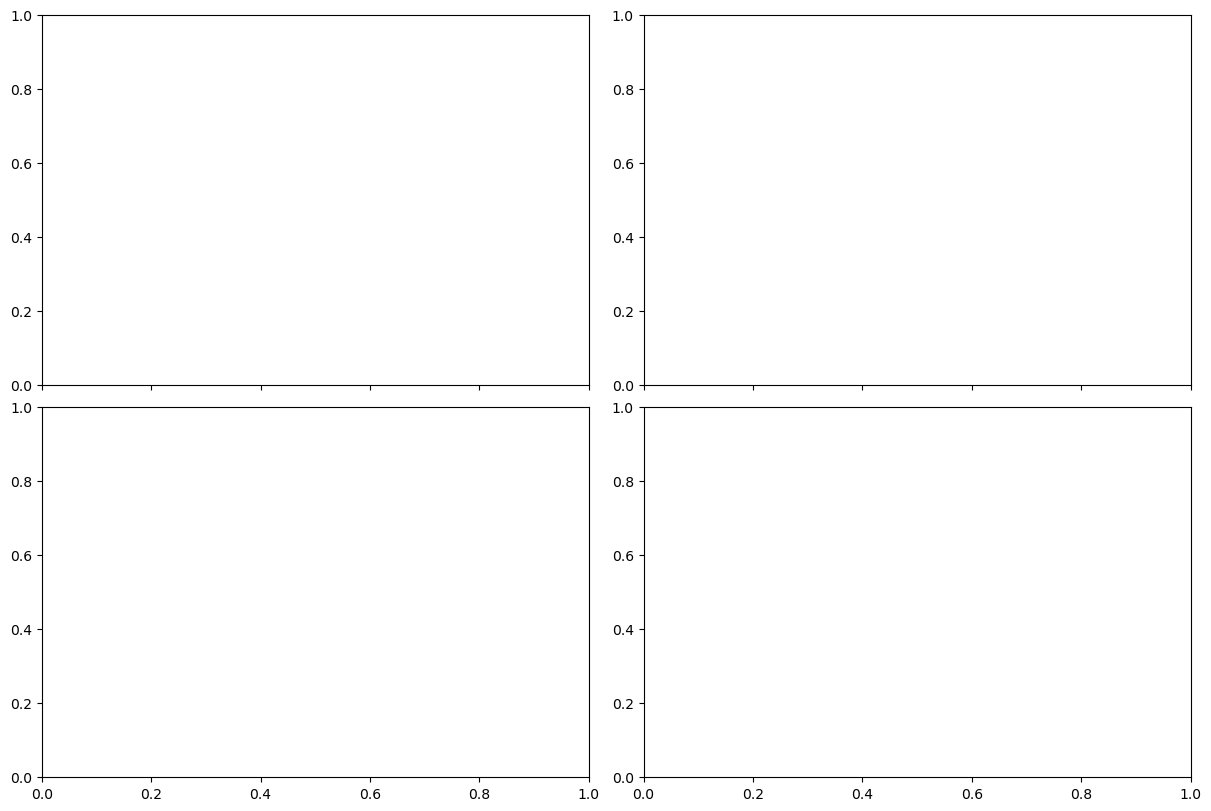

In [ ]:
fig, axes = plot_controller_power_vs_period(
    sweep_results,
    power_var="generated_power",
)
plt.show()

In [ ]:
def plot_controller_power_vs_amplitude(
    sweep_results,
    power_var="generated_power",
    controller_order=("P", "P_coupled", "PI", "PI_coupled"),
):
    data = sweep_results[power_var].sortby("wave_period").sortby("amplitude")

    wave_periods_sorted = data["wave_period"].values

    n_period = len(wave_periods_sorted)
    ncols = 3
    nrows = int(np.ceil(n_period / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 4 * nrows),
        sharex=True,
        constrained_layout=True,
    )

    axes = np.asarray(axes).ravel()

    for iT, wave_period in enumerate(wave_periods_sorted):
        ax = axes[iT]

        for controller in controller_order:
            if controller not in data["controller"].values:
                continue

            y = data.sel(controller=controller, wave_period=wave_period).values
            x = data["amplitude"].values

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=1.8,
                label=controller,
            )

        ax.set_title(f"Wave period = {wave_period:g} s")
        ax.set_xlabel("Wave amplitude [m]")
        ax.set_ylabel("Generated electrical power [W]")
        ax.grid(True, alpha=0.3)
        ax.legend()

    # Hide unused axes
    for j in range(n_period, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Controller comparison: power vs wave amplitude", fontsize=14)

    return fig, axes

In [ ]:
fig, axes = plot_controller_power_vs_amplitude(
    sweep_results,
    power_var="generated_power",
)
plt.show()

In [ ]:
def plot_controller_power_heatmaps(
    sweep_results,
    power_var="generated_power",
    controller_order=("P", "P_coupled", "PI", "PI_coupled"),
):
    data = sweep_results[power_var].sortby("wave_period").sortby("amplitude")

    n_ctrl = len(controller_order)
    ncols = 2
    nrows = int(np.ceil(n_ctrl / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(12, 4.5 * nrows),
        constrained_layout=True,
    )

    axes = np.asarray(axes).ravel()

    # Common color scale across controllers
    vmin = float(data.min(skipna=True).values)
    vmax = float(data.max(skipna=True).values)

    for ic, controller in enumerate(controller_order):
        ax = axes[ic]

        if controller not in data["controller"].values:
            ax.set_visible(False)
            continue

        da = data.sel(controller=controller)

        im = ax.imshow(
            da.values,
            origin="lower",
            aspect="auto",
            extent=[
                float(da["amplitude"].values.min()),
                float(da["amplitude"].values.max()),
                float(da["wave_period"].values.min()),
                float(da["wave_period"].values.max()),
            ],
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(controller)
        ax.set_xlabel("Wave amplitude [m]")
        ax.set_ylabel("Wave period [s]")

    for j in range(n_ctrl, len(axes)):
        axes[j].set_visible(False)

    cbar = fig.colorbar(im, ax=axes[:n_ctrl], shrink=0.9)
    cbar.set_label("Generated electrical power [W]")

    fig.suptitle("Generated power heatmaps by controller", fontsize=14)

    return fig, axes

In [ ]:
fig, axes = plot_controller_power_heatmaps(
    sweep_results,
    power_var="generated_power",
)
plt.show()

In [ ]:
fig, axes = plot_controller_power_vs_period(
    sweep_results,
    power_var="power_improvement_pct",
    controller_order=("P_coupled", "PI", "PI_coupled"),
)

for ax in np.asarray(axes).ravel():
    if ax.get_visible():
        ax.set_ylabel(f"Improvement over {baseline_controller} [%]")
        ax.axhline(0.0, color="k", linewidth=1.0, alpha=0.5)

plt.show()

In [ ]:
baseline_controller = "P"

baseline_power = sweep_results["generated_power"].sel(controller=baseline_controller)

sweep_results["power_improvement_pct"] = (
    100.0
    * (
        sweep_results["generated_power"]
        - baseline_power
    )
    / np.abs(baseline_power)
)

sweep_results["power_improvement_pct"].attrs["units"] = "%"
sweep_results["power_improvement_pct"].attrs["description"] = (
    f"Power improvement relative to {baseline_controller}"
)

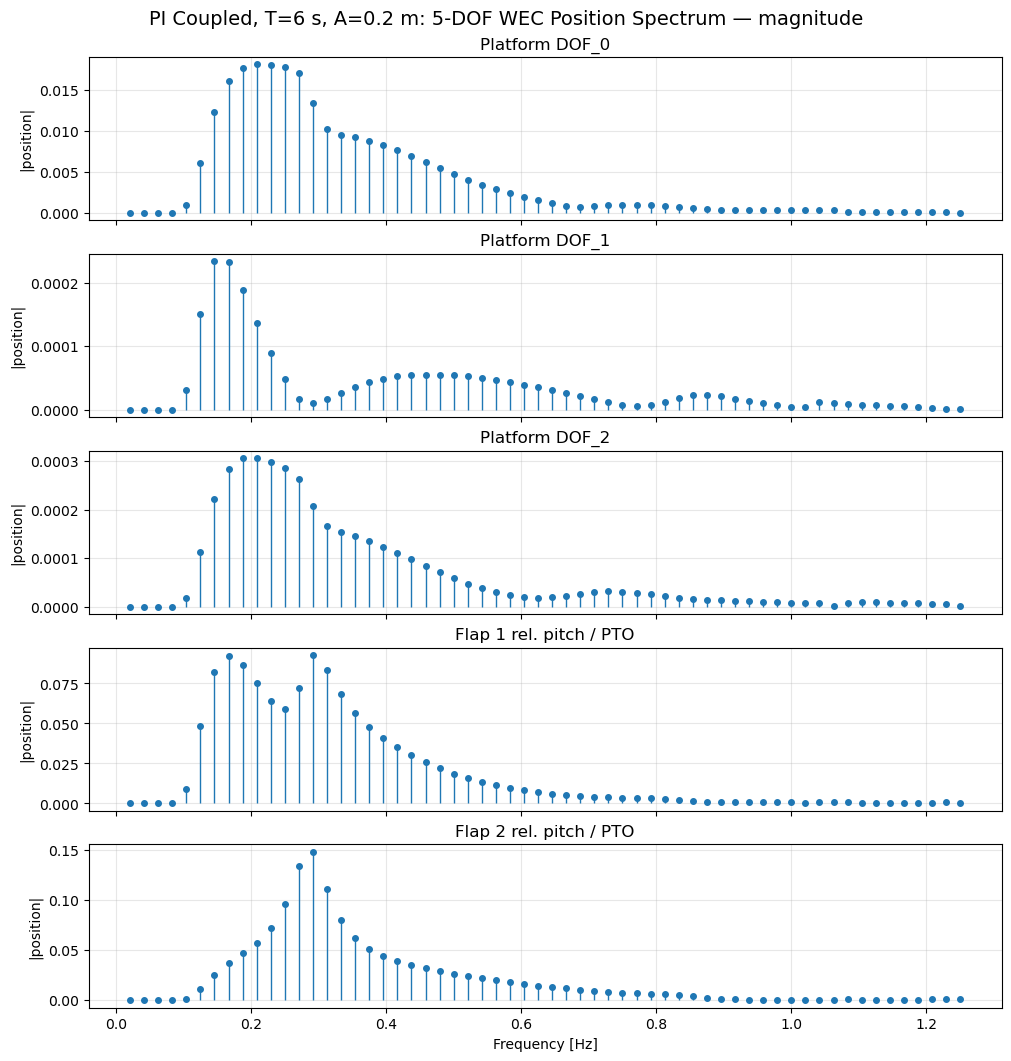

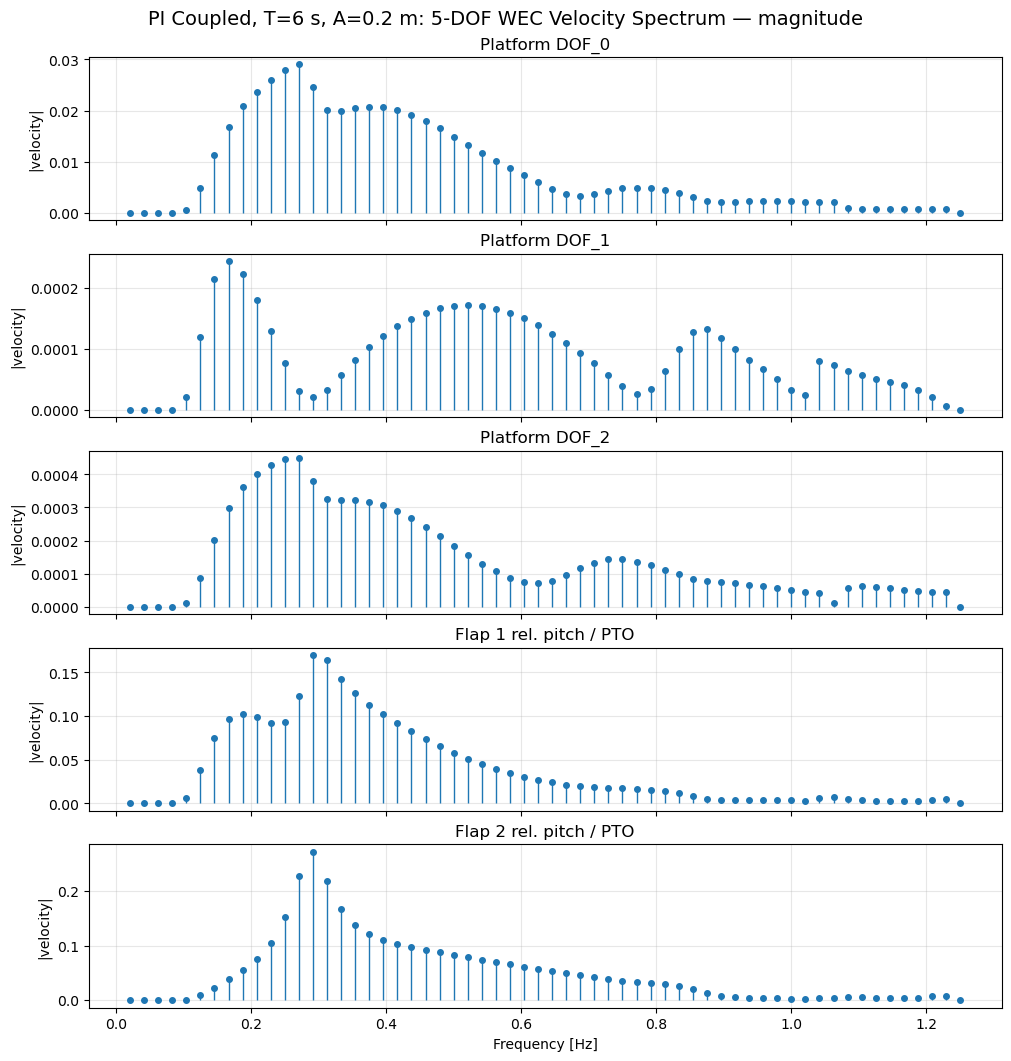

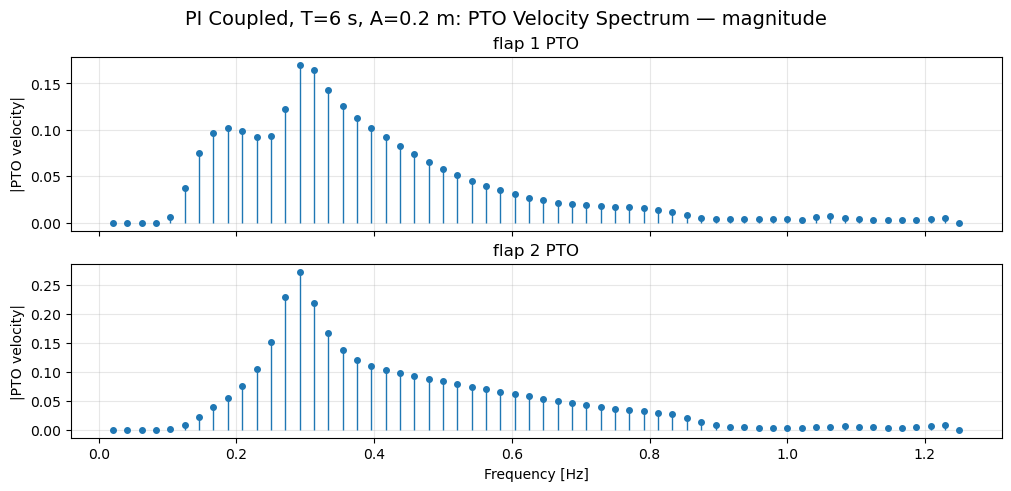

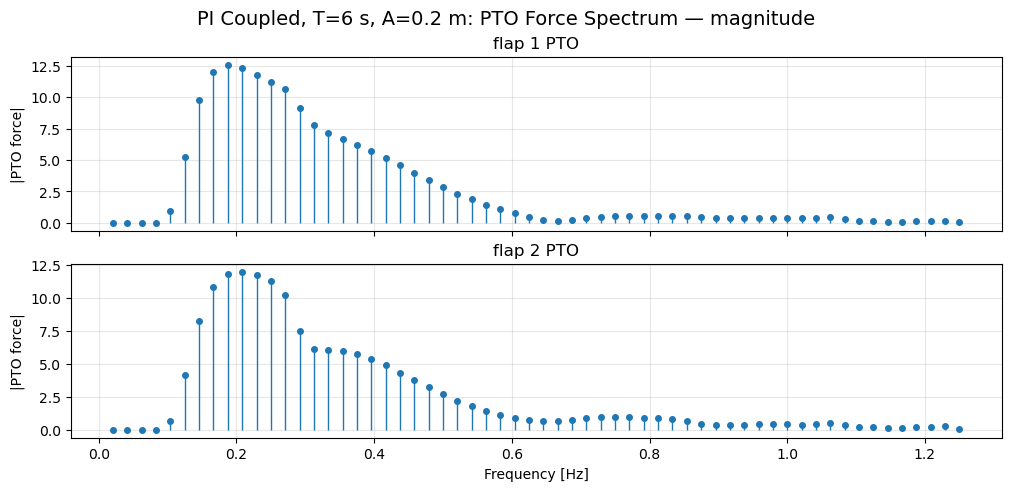

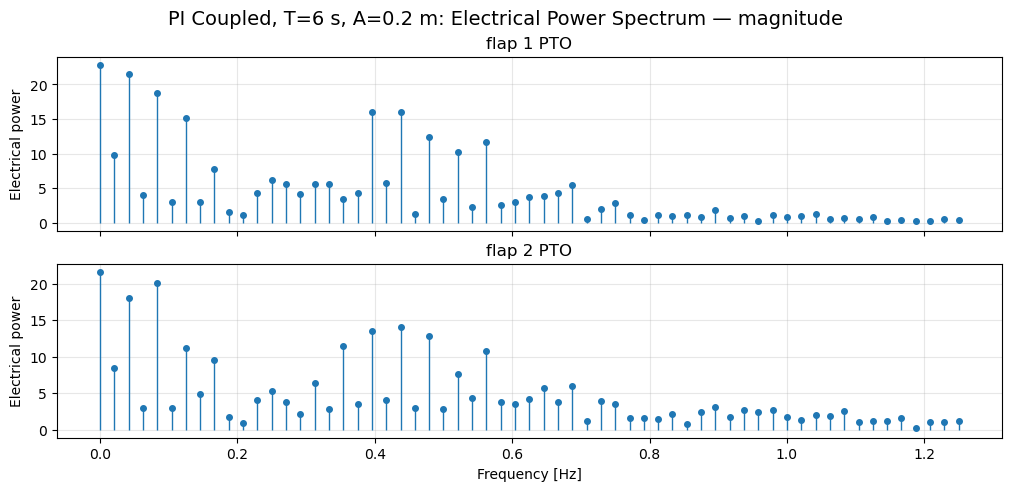

In [ ]:
selected_period = 6.0
selected_amplitude = 0.2

selected_case = full_results[(selected_period, selected_amplitude)]

pi_coupled_plots = study.plot_frequency_domain_case(
    selected_case,
    case_name=f"PI Coupled, T={selected_period:g} s, A={selected_amplitude:g} m",
    realization_idx=0,
    skip_zero_for_motion=True,
    skip_zero_for_power=False,
    power_plot_mode="magnitude",
)